# Component Decomposition of Global Mean Sea Level Rise

This notebook implements the staged component decomposition:

1. **Thermosteric calibration** — Bayesian level-space fit to steric component
2. **Stage 1b** — Physically-motivated two-layer ocean model
3. **Component-level fits** — Observation-constrained Bayesian fits for each SLR component
4. **Greenland physics decomposition** — Joint SMB + discharge model
5. **Component projections** — MC projections under SSP scenarios
6. **Validation** — Historical budget closure + IPCC comparison

**Dependencies:** , , ,
, , , 

---

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

from slr_data_readers import (
    read_berkeley_earth,
    read_glambie_global, read_glambie_regional,
    read_imbie_greenland, read_imbie_east_antarctica,
    read_imbie_antarctic_peninsula, read_imbie_antarctica,
    read_imbie_all, read_imbie_west_antarctica,
    read_ipcc_ar6_component, list_ipcc_ar6_components,
    read_noaa_oni, read_noaa_mei, read_berkeley_earth_gridded,
)
from slr_forecast.readers.ice_sheets import (
    read_mouginot2019_greenland,
    read_mankoff2021_greenland,
)
from bayesian_dols import (
    build_level_design_vectors, fit_bayesian_level,
    calibrate_exponential_prior,
    fit_bayesian_thermosteric, solve_twolayer_ode,
    check_convergence,
    fit_bayesian_greenland,
)
from slr_analysis import compute_kinematics
from slr_projections import (
    project_component_level_ensemble,
    project_thermosteric_ensemble,
)
from component_analysis import (
    annualize_imbie, apply_sigma_taper,
    restrict_and_fit, model_ensemble_draws,
    eval_model_median, compute_component_rates,
    build_full_temperature_scenario,
    compute_variance_fractions,
)
from component_projections import (
    sample_a4_wais, A4_SCENARIOS,
    RHEOLOGY_FACTOR_MEDIAN, RHEOLOGY_FACTOR_SIGMA, STOCHASTIC_CV,
    read_ipcc_component_nc, ipcc_extract,
    get_our_stats, get_ipcc_stats,
    safe_float, stats_dict, export_results_json,
)
from component_plotting import (
    plot_frederikse_overview, plot_model_fits,
    plot_residual_validation, plot_rate_vs_temperature,
    plot_component_projections, plot_variance_decomposition,
    plot_budget_closure, plot_ipcc_comparison,
    format_summary_table, plot_component_rates,
    SSP_COLORS, COMP_COLORS, PANEL_COLORS,
)

# Paths
H5_PATH   = '../data/processed/slr_processed_data.h5'
RAW_DIR   = '../data/raw'
FIG_DIR   = '../figures'
COMP_DIR  = f'{RAW_DIR}/ipcc_ar6/slr/ar6/global/dist_components'
CONF_BASE = f'{RAW_DIR}/ipcc_ar6/slr/ar6/global/confidence_output_files'

# Constants
M_TO_MM = 1000.0
BASELINE_YEAR = 2005.0
N_SAMPLES = 2000

print('Imports OK')

Imports OK


## 1. Data Loading

Load Frederikse et al. (2020) budget-closure reconstruction, Mouginot/Mankoff
Greenland datasets, and temperature data.

In [5]:
# ── Load Frederikse component-level data ──
df_fred = pd.read_hdf(H5_PATH, 'derived/df_frederikse_thermo')

fred_year = df_fred['year'].values
fred_gmsl = df_fred['gmsl'].values
fred_gmsl_sigma = df_fred['gmsl_sigma'].values
fred_steric = df_fred['steric'].values
fred_steric_sigma = df_fred['steric_sigma'].values
fred_glaciers = df_fred['glaciers'].values
fred_glaciers_sigma = df_fred['glaciers_sigma'].values
fred_greenland = df_fred['greenland'].values
fred_greenland_sigma = df_fred['greenland_sigma'].values
fred_antarctica = df_fred['antarctica'].values
fred_antarctica_sigma = df_fred['antarctica_sigma'].values
fred_tws = df_fred['tws'].values
fred_tws_sigma = df_fred['tws_sigma'].values
fred_thermo_gmsl = df_fred['thermodynamic_gmsl'].values
fred_barystatic = df_fred['barystatic'].values
fred_barystatic_sigma = df_fred['barystatic_sigma'].values

print(f'Frederikse budget: {fred_year[0]:.0f}–{fred_year[-1]:.0f} ({len(fred_year)} years)')
print(f'  GMSL at 2018: {fred_gmsl[-1]*M_TO_MM:6.1f} mm')

# ── Load Mouginot et al. (2019) Greenland (1972–2018) ──
df_mouginot = read_mouginot2019_greenland(
    f'{RAW_DIR}/ice_sheets/greenland/mouginot2019_data.xlsx')
mou_year = df_mouginot['decimal_year'].values.astype(float)
mou_greenland = df_mouginot['cumulative_mb'].values
mou_greenland_sigma = df_mouginot['cumulative_mb_sigma'].values
_bl_mou = np.argmin(np.abs(mou_year - BASELINE_YEAR))
mou_greenland = mou_greenland - mou_greenland[_bl_mou]

# ── Load Mankoff et al. (2021) Greenland (1986–2023) ──
df_mankoff = read_mankoff2021_greenland(
    f'{RAW_DIR}/ice_sheets/greenland/mankoff/MB_SMB_D_BMB_ann.csv',
    obs_only=True)
man_year = df_mankoff['decimal_year'].values.astype(float)
man_rate = df_mankoff['mb_rate'].values
man_rate_sigma = df_mankoff['mb_rate_sigma'].values
man_greenland = np.cumsum(man_rate)
man_greenland_sigma = np.sqrt(np.cumsum(man_rate_sigma**2))
_bl_man = np.argmin(np.abs(man_year - BASELINE_YEAR))
man_greenland = man_greenland - man_greenland[_bl_man]

# ── Build combined Greenland array ──
grn_year_combined = np.concatenate([mou_year, man_year])
grn_combined = np.concatenate([mou_greenland, man_greenland])
grn_sigma_combined = np.concatenate([mou_greenland_sigma, man_greenland_sigma])
sort_idx = np.argsort(grn_year_combined)
grn_year_combined = grn_year_combined[sort_idx]
grn_combined = grn_combined[sort_idx]
grn_sigma_combined = grn_sigma_combined[sort_idx]

print(f'Mouginot: {mou_year[0]:.0f}–{mou_year[-1]:.0f} ({len(mou_year)} pts)')
print(f'Mankoff:  {man_year[0]:.0f}–{man_year[-1]:.0f} ({len(man_year)} pts)')
print(f'Combined: {grn_year_combined[0]:.0f}–{grn_year_combined[-1]:.0f} ({len(grn_year_combined)} pts)')

# ── Load GlaMBIE global glacier consensus (2000–2023) ──
# Primary glacier calibration dataset: observational multi-method consensus.
df_glac = read_glambie_global(f'{RAW_DIR}/glaciers/0_global_glambie_consensus.csv')
glac_year = df_glac['decimal_year'].values
glac_rate = df_glac['mass_balance'].values          # m/yr SLE, positive = SLR
glac_rate_sigma = df_glac['mass_balance_sigma'].values

# Cumulative glacier SLR contribution (integrate annual rates)
glac_cumul = np.cumsum(glac_rate)                    # m SLE
glac_cumul_sigma = np.sqrt(np.cumsum(glac_rate_sigma**2))
_bl_gl = np.argmin(np.abs(glac_year - BASELINE_YEAR))
glac_cumul = glac_cumul - glac_cumul[_bl_gl]

# Total glacier ice volume for projection cap (Farinotti et al. 2019 via RGI)
V_GLACIER_TOTAL_M = 0.32   # meters SLE

print(f'GlaMBIE:  {glac_year[0]:.0f}–{glac_year[-1]:.0f} ({len(glac_year)} pts)')
print(f'  Cumulative at {glac_year[-1]:.0f}: {glac_cumul[-1]*M_TO_MM:.1f} mm SLE')
print(f'  Mean rate: {np.mean(glac_rate)*M_TO_MM:.2f} mm/yr')

Frederikse budget: 1900–2018 (119 years)
  GMSL at 2018:   35.6 mm
Mouginot: 1972–2018 (47 pts)
Mankoff:  1986–2024 (38 pts)
Combined: 1972–2024 (85 pts)


In [6]:
# ── Load temperature data ──
df_temp = pd.read_hdf(H5_PATH, 'harmonized/df_berkeley_h')
temp_time_monthly = (df_temp.index.year + (df_temp.index.month - 0.5) / 12.0).values
temp_monthly = df_temp['temperature'].values
print(f'Berkeley Earth: {temp_time_monthly[0]:.1f}–{temp_time_monthly[-1]:.1f} ({len(temp_monthly)} months)')

# ── IPCC projected temperatures ──
ssp_temp_map = {
    'SSP1-2.6': 'projections/temp/SSP1_2_6',
    'SSP2-4.5': 'projections/temp/SSP2_4_5',
    'SSP5-8.5': 'projections/temp/SSP5_8_5',
}
ipcc_temp_proj = {}
for ssp_name, h5_key in ssp_temp_map.items():
    df_ssp = pd.read_hdf(H5_PATH, h5_key)
    ipcc_temp_proj[ssp_name] = df_ssp
    print(f'  {ssp_name}: {df_ssp["decimal_year"].iloc[0]:.0f}–{df_ssp["decimal_year"].iloc[-1]:.0f}')

# ── Load Greenland regional temperature (Berkeley Earth 1° gridded NetCDF) ──
GRIDDED_PATH = f'{RAW_DIR}/gmst/berkEarth_Global_TAVG_Gridded_1deg.nc'
df_gr_temp = read_berkeley_earth_gridded(GRIDDED_PATH)  # defaults to Greenland

gr_temp_raw = df_gr_temp['temperature'].values
gr_time_monthly = df_gr_temp['decimal_year'].values

# Rebaseline: Berkeley default (1951-1980) → our convention (1995-2005)
bl_mask_gr = (gr_time_monthly >= 1995.0) & (gr_time_monthly < 2006.0)
gr_temp_monthly = gr_temp_raw - np.nanmean(gr_temp_raw[bl_mask_gr])

# Drop NaN months
valid_gr = np.isfinite(gr_temp_monthly)
gr_temp_monthly = gr_temp_monthly[valid_gr]
gr_time_monthly = gr_time_monthly[valid_gr]

print(f'Greenland T (gridded): {gr_time_monthly[0]:.1f}–{gr_time_monthly[-1]:.1f} '
      f'({len(gr_temp_monthly)} months, '
      f'{df_gr_temp.attrs.get("n_cells", "?")} grid cells)')

Berkeley Earth: 1850.0–2025.0 (2100 months)
  SSP1-2.6: 2015–2099
  SSP2-4.5: 2015–2099
  SSP5-8.5: 2015–2099
Greenland T (gridded): 1850.0–2026.1 (2114 months, 774 grid cells)


## 2. Frederikse Budget Overview

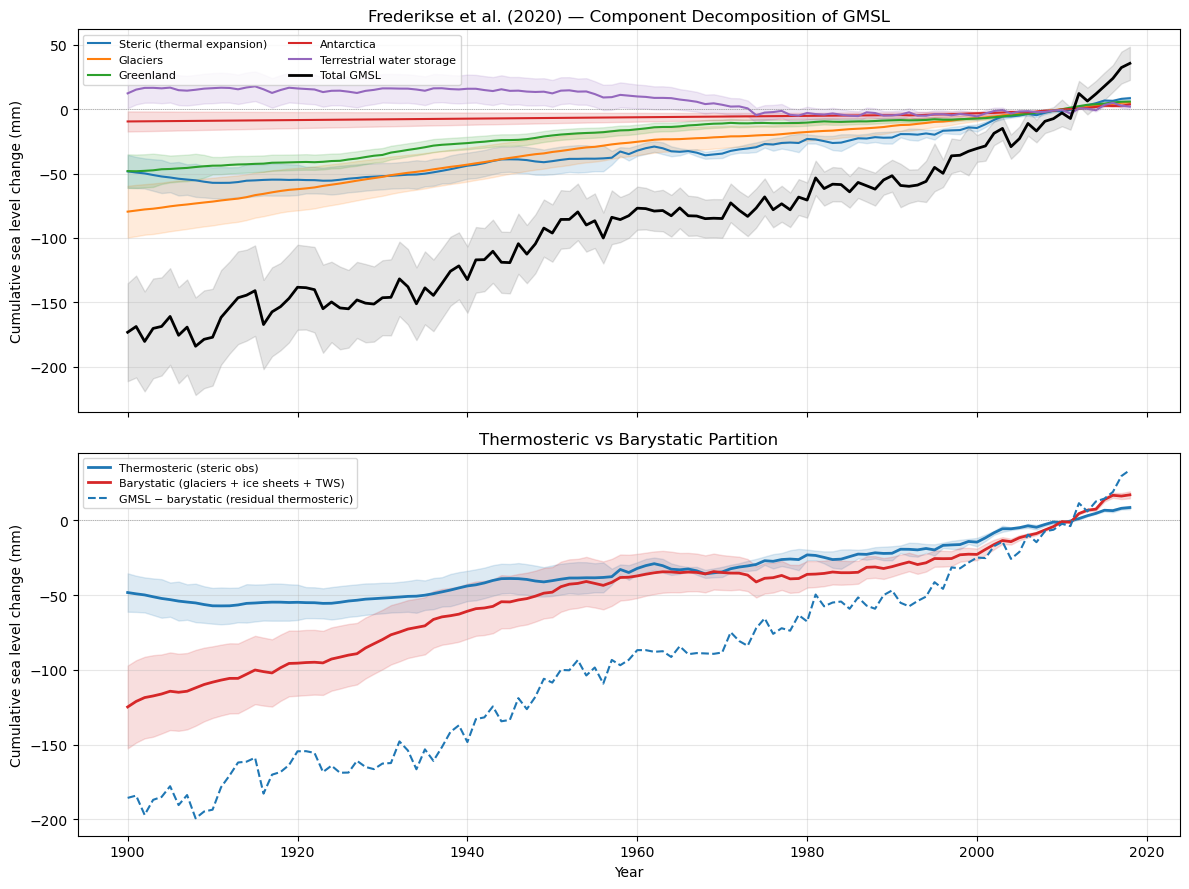

In [7]:
plot_frederikse_overview(
    fred_year, fred_gmsl, fred_gmsl_sigma,
    fred_steric, fred_steric_sigma,
    fred_glaciers, fred_glaciers_sigma,
    fred_greenland, fred_greenland_sigma,
    fred_antarctica, fred_antarctica_sigma,
    fred_tws, fred_tws_sigma,
    fred_barystatic, fred_barystatic_sigma,
    fred_thermo_gmsl,
    save_path=f'{FIG_DIR}/component_frederikse_overview.png',
)

## 3. Thermosteric Calibration

Fit the Bayesian level-space rate–temperature model to the **steric component**:
rate_thermo(t) = a·T² + b·T + c.  Thermal expansion is approximately linear
in GMST, so we expect a ≈ 0.

In [8]:
# ── Rebase to 2005 baseline ──
baseline_idx = np.argmin(np.abs(fred_year - BASELINE_YEAR))
steric_rebase = fred_steric - fred_steric[baseline_idx]
steric_sigma = fred_steric_sigma.copy()
gmsl_rebase = fred_gmsl - fred_gmsl[baseline_idx]
gmsl_sigma = fred_gmsl_sigma.copy()

# ── Build design vectors ──
design = build_level_design_vectors(
    temperature_monthly=temp_monthly,
    time_monthly=temp_time_monthly,
    obs_times=fred_year,
)
I2_obs = design['I2_obs']
I1_obs = design['I1_obs']
I0_obs = design['I0_obs']

# ── Prior configuration ──
PRIOR_SCALE_A_THERMO = calibrate_exponential_prior(prob_exceed=0.10, threshold=0.002)
PRIOR_SCALE_B_THERMO = 0.005
PRIOR_C_MEAN_THERMO = 0.0005
PRIOR_C_SIGMA_THERMO = 0.002
PRIOR_SIGMA_EXTRA_THERMO = 0.002
PRIOR_H0_SIGMA_THERMO = 0.010

# ── Fit ──
result_thermo = fit_bayesian_level(
    H_obs=steric_rebase, sigma_obs=steric_sigma,
    I2_obs=I2_obs, I1_obs=I1_obs, I0_obs=I0_obs,
    prior_scale_a=PRIOR_SCALE_A_THERMO,
    prior_scale_b=PRIOR_SCALE_B_THERMO,
    prior_c_mean=PRIOR_C_MEAN_THERMO,
    prior_c_sigma=PRIOR_C_SIGMA_THERMO,
    prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_THERMO,
    prior_H0_sigma=PRIOR_H0_SIGMA_THERMO,
    n_samples=4000, n_walkers=32, n_burnin=2000, thin=2, seed=42,
)

a_th = result_thermo.posterior_samples[:, 0]
b_th = result_thermo.posterior_samples[:, 1]
c_th = result_thermo.posterior_samples[:, 2]
r2_thermo = result_thermo.r2

print('THERMOSTERIC CALIBRATION')
print('=' * 65)
for name, s, unit in [
    ('a_th', a_th * M_TO_MM, 'mm/yr/°C²'),
    ('b_th', b_th * M_TO_MM, 'mm/yr/°C'),
    ('c_th', c_th * M_TO_MM, 'mm/yr'),
]:
    p5, med, p95 = np.percentile(s, [5, 50, 95])
    print(f'  {name:12s} = {med:7.3f} [{p5:.3f}, {p95:.3f}] {unit}')
print(f'  R² = {r2_thermo:.4f}')

Bayesian level-space fit: n=119 observations, ndim=5
  Priors: a~Exp(mean=0.87 mm/yr/°C²), b~HN(5.0 mm/yr/°C), c~N(0.5, 2.0 mm/yr), σ_extra~HC(2.0 mm)
  OLS init: a=-0.233, b=0.676, c=0.950 mm/yr, σ_extra=2.50 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:08<00:00, 736.73it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.008  ESS_bulk=262  ESS_tail=569
    alpha0: R-hat=1.009  ESS_bulk=273  ESS_tail=456
    trend: R-hat=1.035  ESS_bulk=189  ESS_tail=748
    log_sigma_extra: R-hat=1.023  ESS_bulk=264  ESS_tail=544
    H0: R-hat=1.025  ESS_bulk=237  ESS_tail=424
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.259, b=1.108, c=0.988 mm/yr
  σ_extra: median=1.14 mm [0.78, 1.59]
  R² = 0.9795,  acceptance = 0.53
THERMOSTERIC CALIBRATION
  a_th         =   0.239 [0.031, 0.558] mm/yr/°C²
  b_th         =   1.096 [0.935, 1.327] mm/yr/°C
  c_th         =   0.988 [0.957, 1.020] mm/yr
  R² = 0.9795


Bayesian level-space fit: n=119 observations, ndim=5
  Priors: a~Exp(mean=2.17 mm/yr/°C²), b~HN(10.0 mm/yr/°C), c~N(2.0, 5.0 mm/yr), σ_extra~HC(5.0 mm)
  OLS init: a=3.118, b=3.896, c=2.476 mm/yr, σ_extra=9.31 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:08<00:00, 705.73it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.025  ESS_bulk=213  ESS_tail=742
    alpha0: R-hat=1.028  ESS_bulk=201  ESS_tail=633
    trend: R-hat=1.012  ESS_bulk=285  ESS_tail=1016
    log_sigma_extra: R-hat=1.024  ESS_bulk=231  ESS_tail=291
    H0: R-hat=1.016  ESS_bulk=253  ESS_tail=753
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=4.459, b=4.994, c=2.535 mm/yr
  σ_extra: median=1.59 mm [0.09, 4.01]
  R² = 0.9696,  acceptance = 0.54


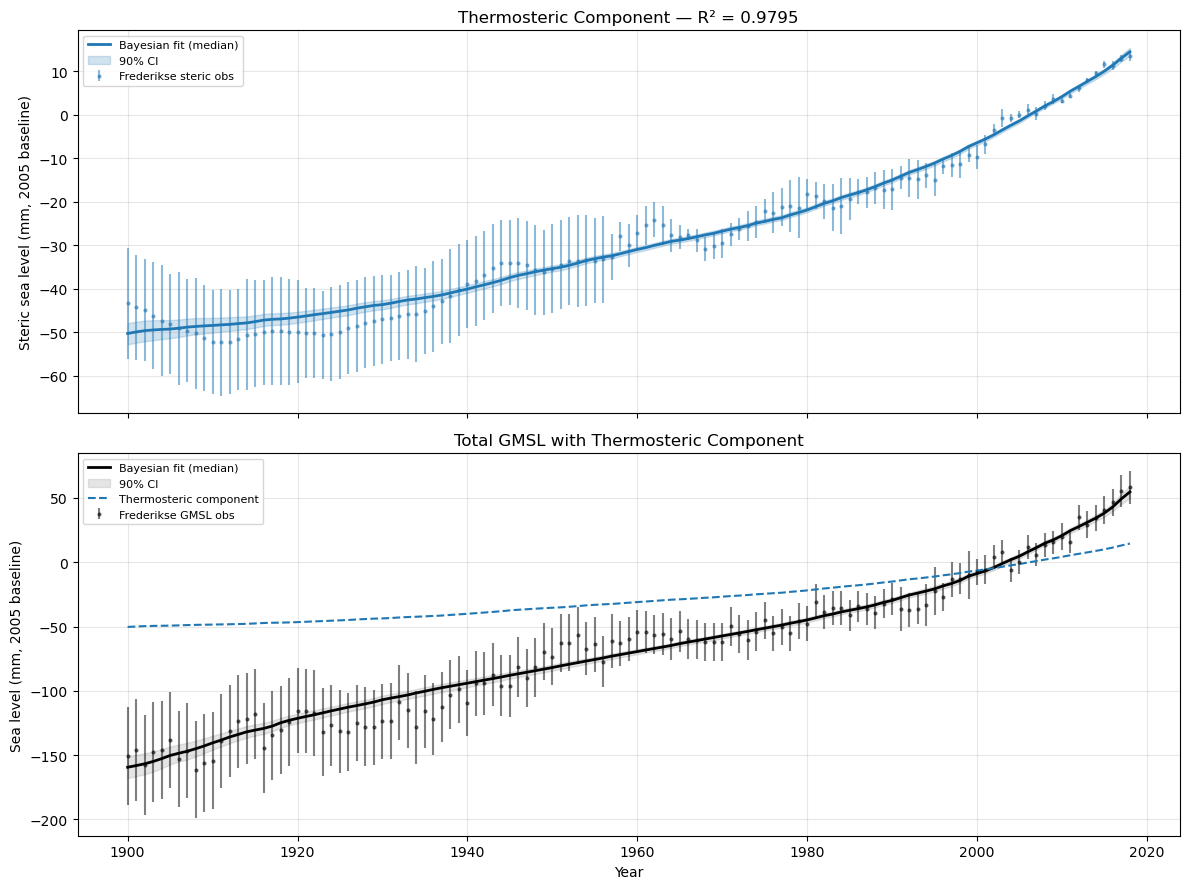

In [9]:
# ── Fit total GMSL for comparison ──
PRIOR_SCALE_A_TOTAL = calibrate_exponential_prior(prob_exceed=0.10, threshold=0.005)

result_total = fit_bayesian_level(
    H_obs=gmsl_rebase, sigma_obs=gmsl_sigma,
    I2_obs=I2_obs, I1_obs=I1_obs, I0_obs=I0_obs,
    prior_scale_a=PRIOR_SCALE_A_TOTAL,
    prior_scale_b=0.010, prior_c_mean=0.002, prior_c_sigma=0.005,
    prior_sigma_extra_scale=0.005, prior_H0_sigma=0.050,
    n_samples=4000, n_walkers=32, n_burnin=2000, thin=2, seed=43,
)

a_total = result_total.posterior_samples[:, 0]
b_total = result_total.posterior_samples[:, 1]
c_total = result_total.posterior_samples[:, 2]

# ── Model fit figure ──
H_ens_th = model_ensemble_draws(result_thermo, I2_obs, I1_obs, I0_obs)
H_ens_tot = model_ensemble_draws(result_total, I2_obs, I1_obs, I0_obs)

plot_model_fits(
    fred_year, steric_rebase, steric_sigma,
    gmsl_rebase, gmsl_sigma,
    H_ens_th, H_ens_tot, r2_thermo,
    save_path=f'{FIG_DIR}/component_stage1_fit.png',
)

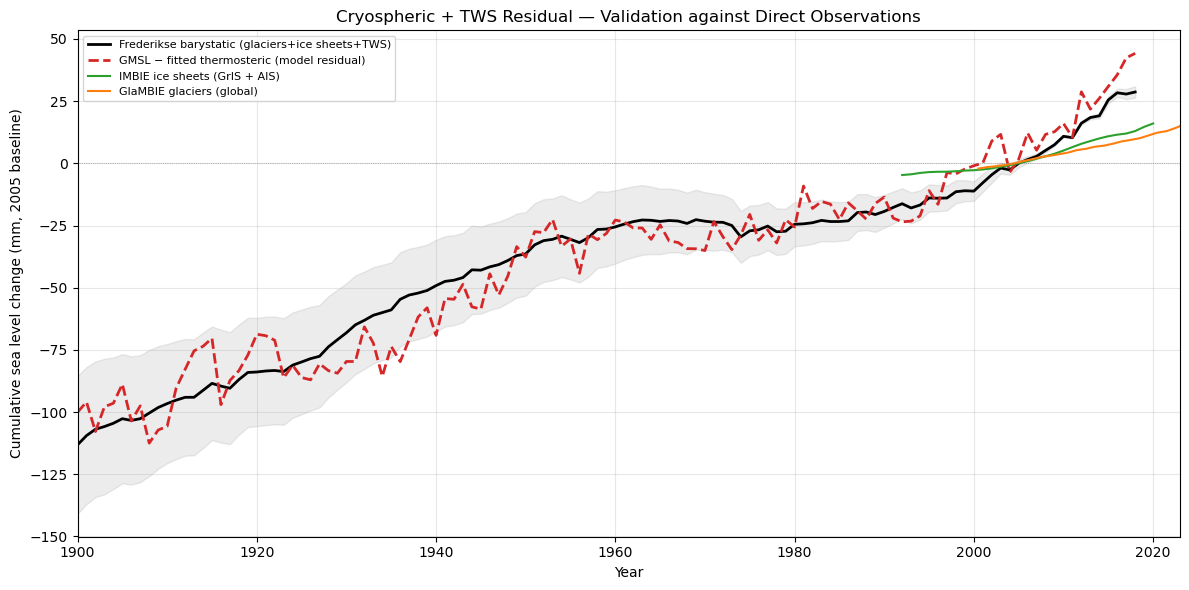

In [10]:
# ── Cryospheric residual ──
barystatic_rebase = fred_barystatic - fred_barystatic[baseline_idx]
H_thermo_median = (np.median(a_th) * I2_obs + np.median(b_th) * I1_obs
                   + np.median(c_th) * I0_obs + np.median(result_thermo.H0_posterior))
resid_model = gmsl_rebase - H_thermo_median

# ── Load validation data ──
df_gris = read_imbie_greenland(f'{RAW_DIR}/ice_sheets/Gt/imbie_greenland_2021_Gt.csv')
df_ais  = read_imbie_antarctica(f'{RAW_DIR}/ice_sheets/Gt/imbie_antarctica_2021_Gt.csv')
df_glac = read_glambie_global(f'{RAW_DIR}/glaciers/0_global_glambie_consensus.csv')

gris_yr = df_gris['cumulative_mass_balance'].resample('YE').last()
ais_yr = df_ais['cumulative_mass_balance'].resample('YE').last()
ice_years = gris_yr.index.year
gris_slr = -gris_yr.values
ais_slr = -ais_yr.values
idx_2005_ice = np.argmin(np.abs(ice_years - 2005))
ice_slr = (gris_slr + ais_slr) - (gris_slr[idx_2005_ice] + ais_slr[idx_2005_ice])

glac_years = df_glac['decimal_year'].values
glac_cumul_mm = np.cumsum(df_glac['mass_balance'].values) * M_TO_MM
idx_2005_gl = np.argmin(np.abs(glac_years - 2005))
glac_cumul_mm -= glac_cumul_mm[idx_2005_gl]

plot_residual_validation(
    fred_year, barystatic_rebase, fred_barystatic_sigma,
    resid_model, ice_years, ice_slr, glac_years, glac_cumul_mm,
    save_path=f'{FIG_DIR}/component_stage1_residual.png',
)

## 4. Stage 1b: Physical Thermosteric Model

Introduce state variable S_u(t) for effective ocean temperature with
relaxation time τ_u:  dS_u/dt = (T − S_u)/τ_u,  η(t) = a·S_u² + b·S_u + c·t + H₀

In [12]:
# ── Single-layer physical model ──
# b_therm and log_tau_u are strongly correlated (higher τ → lower b),
# requiring more walkers + longer chains to mix. Use 128 walkers,
# 8000 burn-in, 20000 production, thin=4 → ~5000 effective samples.
result_phys = fit_bayesian_thermosteric(
    H_obs=steric_rebase, sigma_obs=steric_sigma,
    T_monthly=temp_monthly, time_monthly=temp_time_monthly, obs_times=fred_year,
    n_layers=1,
    prior_scale_a=0.22, prior_scale_b=0.15,
    prior_c_mean=0.0003, prior_c_sigma=0.0005,
    prior_sigma_extra_scale=0.003, prior_H0_sigma=0.010,
    n_samples=20000, n_walkers=128, n_burnin=8000, thin=4,
    progress=True, seed=42,
)

a_phys = result_phys.posterior_samples[:, 0]
b_phys = result_phys.posterior_samples[:, 1]
tau_u_phys = result_phys.tau_u_posterior

# ── Convergence check ──
from bayesian_dols import check_convergence
conv = check_convergence(result_phys.trace, quiet=False)
if result_phys.sampler_diagnostics and 'acceptance_fraction' in result_phys.sampler_diagnostics:
    print(f'  Acceptance fraction: {result_phys.sampler_diagnostics["acceptance_fraction"]:.3f}')

print('\nSTAGE 1b: SINGLE-LAYER PHYSICAL MODEL')
print('=' * 65)
for name, s, unit in [
    ('a (curvature)', a_phys, 'm/°C²'),
    ('b (expansion)',  b_phys, 'm/°C'),
    ('τ_u', tau_u_phys, 'yr'),
]:
    med = np.median(s)
    lo, hi = np.percentile(s, [3, 97])
    print(f'  {name:25s}: {med:.5f} {unit}  94% HDI [{lo:.5f}, {hi:.5f}]')
print(f'  R² = {result_phys.r2:.4f}')
print(f'  Stage 1 (instantaneous) R² = {r2_thermo:.4f}')

  Annual grid: 175 points (1850–2024), monthly: 2100 points
  OLS init: a=0.0251 m/°C², b=0.0403 m/°C, c=0.396 mm/yr, τ_u=8.0 yr
  Running emcee: 128 walkers, 8000 burn-in + 20000 production (1-layer, 6 params)...


100%|███████████████████████████████████████████████████████████████| 28000/28000 [21:10<00:00, 22.03it/s]


  Convergence diagnostics:
    a_therm: R-hat=1.005  ESS_bulk=657  ESS_tail=1149
    b_therm: R-hat=1.009  ESS_bulk=424  ESS_tail=596
    c_therm: R-hat=1.010  ESS_bulk=693  ESS_tail=1647
    log_tau_u: R-hat=1.009  ESS_bulk=432  ESS_tail=667
    log_sigma_extra: R-hat=1.007  ESS_bulk=1002  ESS_tail=2026
    H0: R-hat=1.011  ESS_bulk=587  ESS_tail=1242
  All diagnostics OK (R-hat < 1.05, ESS > 100)

  Posterior mean: a=0.0201 m/°C², b=0.0527 m/°C, c=0.289 mm/yr
  τ_u: median=13.7 yr [8.6, 20.5]
  σ_extra: median=1.14 mm
  R² = 0.9798,  acceptance = 0.47
  a/b ratio: median=0.3833 °C⁻¹  (TEOS-10 expectation ≈ 0.033 °C⁻¹)
  Convergence diagnostics:
    a_therm: R-hat=1.005  ESS_bulk=657  ESS_tail=1149
    b_therm: R-hat=1.009  ESS_bulk=424  ESS_tail=596
    c_therm: R-hat=1.010  ESS_bulk=693  ESS_tail=1647
    log_tau_u: R-hat=1.009  ESS_bulk=432  ESS_tail=667
    log_sigma_extra: R-hat=1.007  ESS_bulk=1002  ESS_tail=2026
    H0: R-hat=1.011  ESS_bulk=587  ESS_tail=1242
  All diagnostics

In [13]:
# ── Two-layer extension ──
result_phys_2L = fit_bayesian_thermosteric(
    H_obs=steric_rebase, sigma_obs=steric_sigma,
    T_monthly=temp_monthly, time_monthly=temp_time_monthly, obs_times=fred_year,
    n_layers=2,
    prior_scale_a=0.22, prior_scale_b=0.15, prior_scale_b_d=0.05,
    prior_c_mean=0.0003, prior_c_sigma=0.0005,
    prior_sigma_extra_scale=0.003, prior_H0_sigma=0.010,
    n_samples=15000, n_walkers=128, n_burnin=6000, thin=1,
    progress=True, seed=43,
)

tau_u_2L = result_phys_2L.tau_u_posterior
tau_d_2L = result_phys_2L.tau_d_posterior
print(f'Two-layer: R² = {result_phys_2L.r2:.4f}')
print(f'  τ_u: {np.median(tau_u_2L):.1f} yr, τ_d: {np.median(tau_d_2L):.0f} yr')

  Annual grid: 175 points (1850–2024), monthly: 2100 points
  OLS init: a=0.0000 m/°C², b=0.0000 m/°C, c=-0.666 mm/yr, τ_u=8.0 yr
  Running emcee: 128 walkers, 6000 burn-in + 15000 production (2-layer, 8 params)...


100%|███████████████████████████████████████████████████████████████| 21000/21000 [28:16<00:00, 12.38it/s]


  Convergence diagnostics:
    a_therm: R-hat=1.015  ESS_bulk=405  ESS_tail=1428
    b_u_therm: R-hat=1.006  ESS_bulk=302  ESS_tail=601
    b_d_therm: R-hat=1.010  ESS_bulk=354  ESS_tail=387
    c_therm: R-hat=1.023  ESS_bulk=366  ESS_tail=1271
    log_tau_u: R-hat=1.011  ESS_bulk=337  ESS_tail=851
    log_tau_d: R-hat=1.010  ESS_bulk=390  ESS_tail=813
    log_sigma_extra: R-hat=1.008  ESS_bulk=468  ESS_tail=953
    H0: R-hat=1.027  ESS_bulk=386  ESS_tail=845
  All diagnostics OK (R-hat < 1.05, ESS > 100)

  Posterior mean: a=0.0202 m/°C², b_u=0.0500 m/°C, b_d=0.0050 m/°C, c=0.295 mm/yr
  τ_u: median=12.9 yr [7.7, 19.7]
  τ_d: median=139 yr [52, 365]
  σ_extra: median=1.15 mm
  R² = 0.9783,  acceptance = 0.37
  a/b ratio: median=0.4062 °C⁻¹  (TEOS-10 expectation ≈ 0.033 °C⁻¹)
Two-layer: R² = 0.9783
  τ_u: 12.9 yr, τ_d: 139 yr


In [14]:
# ── Thermosteric projections (physical model) ──
proj_phys_1L = project_thermosteric_ensemble(
    posterior_samples=result_phys.posterior_samples,
    tau_u_samples=result_phys.tau_u_posterior,
    tau_d_samples=None,
    temperature_projections=ipcc_temp_proj,
    historical_temperature=temp_monthly,
    historical_time=temp_time_monthly,
    baseline_year=BASELINE_YEAR, n_samples=2000, n_layers=1, seed=44,
)

proj_phys_2L = project_thermosteric_ensemble(
    posterior_samples=result_phys_2L.posterior_samples,
    tau_u_samples=result_phys_2L.tau_u_posterior,
    tau_d_samples=result_phys_2L.tau_d_posterior,
    temperature_projections=ipcc_temp_proj,
    historical_temperature=temp_monthly,
    historical_time=temp_time_monthly,
    baseline_year=BASELINE_YEAR, n_samples=2000, n_layers=2, seed=44,
)

ssps_to_plot = ['SSP1-2.6', 'SSP2-4.5', 'SSP5-8.5']
print('Thermosteric projections at 2100 (mm):')
for ssp in ssps_to_plot:
    if ssp in proj_phys_1L['scenarios']:
        df = proj_phys_1L['scenarios'][ssp]
        print(f'  {ssp} 1L: {df["steric"].iloc[-1]*M_TO_MM:.0f} mm')
    if ssp in proj_phys_2L['scenarios']:
        df = proj_phys_2L['scenarios'][ssp]
        print(f'  {ssp} 2L: {df["steric"].iloc[-1]*M_TO_MM:.0f} mm')

Thermosteric projections at 2100 (mm):
  SSP1-2.6 1L: 198 mm
  SSP1-2.6 2L: 198 mm
  SSP2-4.5 1L: 311 mm
  SSP2-4.5 2L: 311 mm
  SSP5-8.5 1L: 590 mm
  SSP5-8.5 2L: 594 mm


## 5. Component-Level Fits

Fit each SLR component using observation-constrained windows.
BIC model selection determines that **linear** models (a=0) are preferred
for all individual components — the aggregate quadratic arises from the
shifting component mixture (Simpson's paradox).

In [15]:
# ── Load EAIS, Peninsula, WAIS from IMBIE mm files ──
import os
IMBIE_MM_DIR = f'{RAW_DIR}/ice_sheets/antarctica'

df_eais_monthly = read_imbie_west_antarctica(
    os.path.join(IMBIE_MM_DIR, 'imbie_east_antarctica_2021_mm.csv'))
df_pen_monthly = read_imbie_west_antarctica(
    os.path.join(IMBIE_MM_DIR, 'imbie_antarctic_peninsula_2021_mm.csv'))
df_wais_monthly = read_imbie_west_antarctica(
    os.path.join(IMBIE_MM_DIR, 'imbie_west_antarctica_2021_mm.csv'))

for df in [df_eais_monthly, df_pen_monthly, df_wais_monthly]:
    df['cumulative_mass_balance_sigma'] = df['cumulative_mass_balance_sigma'].abs()
    df['mass_balance_rate_sigma'] = df['mass_balance_rate_sigma'].abs()

eais_year, eais_rebase, eais_sigma = annualize_imbie(df_eais_monthly)
pen_year, pen_rebase, pen_sigma = annualize_imbie(df_pen_monthly)
wais_year, wais_rebase, wais_sigma = annualize_imbie(df_wais_monthly)

for name, yr, h in [('EAIS', eais_year, eais_rebase),
                     ('Peninsula', pen_year, pen_rebase),
                     ('WAIS', wais_year, wais_rebase)]:
    print(f'{name}: {yr[0]:.0f}–{yr[-1]:.0f}, cumulative: {h[-1]*M_TO_MM:.2f} mm')

# ── Design vectors for IMBIE grid ──
design_imbie = build_level_design_vectors(
    temperature_monthly=temp_monthly, time_monthly=temp_time_monthly,
    obs_times=eais_year,
)
I2_imbie = design_imbie['I2_obs']
I1_imbie = design_imbie['I1_obs']
I0_imbie = design_imbie['I0_obs']

EAIS: 1992–2020, cumulative: -0.00 mm
Peninsula: 1992–2020, cumulative: 0.00 mm
WAIS: 1992–2020, cumulative: 0.01 mm


In [16]:
# ── Prior configurations ──
PRIOR_SCALE_A_GLACIER = calibrate_exponential_prior(prob_exceed=0.10, threshold=0.003)
PRIOR_SCALE_A_GR = calibrate_exponential_prior(prob_exceed=0.20, threshold=0.003)
PRIOR_SCALE_A_EAIS = calibrate_exponential_prior(prob_exceed=0.10, threshold=0.001)
PRIOR_SCALE_A_PEN = calibrate_exponential_prior(prob_exceed=0.10, threshold=0.001)

prior_configs = {
    'Thermosteric': dict(
        prior_scale_a=PRIOR_SCALE_A_THERMO, prior_scale_b=PRIOR_SCALE_B_THERMO,
        prior_c_mean=PRIOR_C_MEAN_THERMO, prior_c_sigma=PRIOR_C_SIGMA_THERMO,
        prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_THERMO, prior_H0_sigma=PRIOR_H0_SIGMA_THERMO,
    ),
    'Glaciers': dict(
        prior_scale_a=PRIOR_SCALE_A_GLACIER, prior_scale_b=0.005,
        prior_c_mean=0.0003, prior_c_sigma=0.002,
        prior_sigma_extra_scale=0.002, prior_H0_sigma=0.010,
    ),
    'Greenland': dict(
        prior_scale_a=PRIOR_SCALE_A_GR, prior_scale_b=0.004,
        prior_c_mean=0.0002, prior_c_sigma=0.00015,
        prior_sigma_extra_scale=0.002, prior_H0_sigma=0.005,
    ),
    'Total GMSL': dict(
        prior_scale_a=PRIOR_SCALE_A_TOTAL, prior_scale_b=0.010,
        prior_c_mean=0.002, prior_c_sigma=0.005,
        prior_sigma_extra_scale=0.005, prior_H0_sigma=0.050,
    ),
}

# ── Observation windows ──
obs_windows = {
    'Thermosteric': (1957, 2018),
    'Glaciers':     (2000, 2023),   # GlaMBIE observational era
    'Greenland':    (1972, 2018),
    'Total GMSL':   (1957, 2018),
}

# ── Taper reference years ──
TAPER_REFS = {
    'Thermosteric': 2005, 'Glaciers': 2000,   # no taper needed (fully observational)
    'Greenland': 2002, 'Total GMSL': 2000,
}

# ── Component data ──
taper_component_data = {
    'Thermosteric': (fred_steric, fred_steric_sigma, fred_year),
    'Glaciers':     (glac_cumul, glac_cumul_sigma, glac_year),  # GlaMBIE obs consensus
    'Greenland':    (grn_combined, grn_sigma_combined, grn_year_combined),
    'Total GMSL':   (fred_gmsl, fred_gmsl_sigma, fred_year),
}

# ── Fit with f_max=1 (baseline taper) ──
FMAX_USE = 1
taper_results = {FMAX_USE: {}}

for name, (H_full, sig_full, yrs_full) in taper_component_data.items():
    ow = obs_windows[name]
    mask = (yrs_full >= ow[0]) & (yrs_full <= ow[1])
    yrs_r = yrs_full[mask]
    H_r = H_full[mask].copy()
    sig_r = sig_full[mask].copy()
    bl_r = np.argmin(np.abs(yrs_r - BASELINE_YEAR))
    H_r -= H_r[bl_r]

    sig_tapered = apply_sigma_taper(sig_r, yrs_r, TAPER_REFS[name], FMAX_USE)

    design_r = build_level_design_vectors(
        temperature_monthly=temp_monthly, time_monthly=temp_time_monthly,
        obs_times=yrs_r)

    # Quadratic
    res_q = fit_bayesian_level(
        H_obs=H_r, sigma_obs=sig_tapered,
        I2_obs=design_r['I2_obs'], I1_obs=design_r['I1_obs'], I0_obs=design_r['I0_obs'],
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2,
        seed=200 + hash(name) % 100, **prior_configs[name])

    # Linear (I2=0)
    res_l = fit_bayesian_level(
        H_obs=H_r, sigma_obs=sig_tapered,
        I2_obs=np.zeros_like(design_r['I2_obs']),
        I1_obs=design_r['I1_obs'], I0_obs=design_r['I0_obs'],
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2,
        seed=300 + hash(name) % 100, **prior_configs[name])

    taper_results[FMAX_USE][name] = {'quad': res_q, 'linear': res_l}
    print(f'{name}: R²_quad={res_q.r2:.4f}, R²_lin={res_l.r2:.4f}')

# ── EAIS and Peninsula (already satellite-era only) ──
for ice_name, ice_data, ice_sigma, seed_base in [
    ('EAIS', eais_rebase, eais_sigma, 55),
    ('Peninsula', pen_rebase, pen_sigma, 56),
]:
    prior_kw = dict(
        prior_scale_a=PRIOR_SCALE_A_EAIS, prior_scale_b=0.002,
        prior_c_mean=0.0, prior_c_sigma=0.001,
        prior_sigma_extra_scale=0.001, prior_H0_sigma=0.002,
    )
    res_q = fit_bayesian_level(
        H_obs=ice_data, sigma_obs=ice_sigma,
        I2_obs=I2_imbie, I1_obs=I1_imbie, I0_obs=I0_imbie,
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2,
        seed=seed_base, **prior_kw)
    res_l = fit_bayesian_level(
        H_obs=ice_data, sigma_obs=ice_sigma,
        I2_obs=np.zeros_like(I2_imbie), I1_obs=I1_imbie, I0_obs=I0_imbie,
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2,
        seed=seed_base + 100, **prior_kw)
    taper_results[FMAX_USE][ice_name] = {'quad': res_q, 'linear': res_l}
    print(f'{ice_name}: R²_quad={res_q.r2:.4f}, R²_lin={res_l.r2:.4f}')

Bayesian level-space fit: n=62 observations, ndim=5
  Priors: a~Exp(mean=0.87 mm/yr/°C²), b~HN(5.0 mm/yr/°C), c~N(0.5, 2.0 mm/yr), σ_extra~HC(2.0 mm)
  OLS init: a=0.137, b=1.340, c=1.029 mm/yr, σ_extra=1.87 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:07<00:00, 778.94it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.037  ESS_bulk=159  ESS_tail=372
    alpha0: R-hat=1.031  ESS_bulk=170  ESS_tail=451
    trend: R-hat=1.014  ESS_bulk=261  ESS_tail=592
    log_sigma_extra: R-hat=1.026  ESS_bulk=146  ESS_tail=365
    H0: R-hat=1.010  ESS_bulk=248  ESS_tail=449
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.151, b=1.313, c=1.030 mm/yr
  σ_extra: median=1.19 mm [0.83, 1.67]
  R² = 0.9796,  acceptance = 0.52
Bayesian level-space fit: n=62 observations, ndim=5
  Priors: a~Exp(mean=0.87 mm/yr/°C²), b~HN(5.0 mm/yr/°C), c~N(0.5, 2.0 mm/yr), σ_extra~HC(2.0 mm)
  OLS init: a=0.000, b=1.276, c=1.033 mm/yr, σ_extra=1.87 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:07<00:00, 783.13it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.018  ESS_bulk=162  ESS_tail=376
    alpha0: R-hat=1.033  ESS_bulk=178  ESS_tail=903
    trend: R-hat=1.032  ESS_bulk=294  ESS_tail=842
    log_sigma_extra: R-hat=1.034  ESS_bulk=228  ESS_tail=547
    H0: R-hat=1.028  ESS_bulk=268  ESS_tail=915
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.869, b=1.226, c=1.031 mm/yr
  σ_extra: median=1.16 mm [0.80, 1.63]
  R² = 0.9795,  acceptance = 0.51
Thermosteric: R²_quad=0.9796, R²_lin=0.9795
Bayesian level-space fit: n=58 observations, ndim=5
  Priors: a~Exp(mean=1.30 mm/yr/°C²), b~HN(5.0 mm/yr/°C), c~N(0.3, 2.0 mm/yr), σ_extra~HC(2.0 mm)
  OLS init: a=-0.469, b=0.328, c=0.666 mm/yr, σ_extra=0.18 mm


...

  Convergence diagnostics:
    dalpha_dT: R-hat=1.015  ESS_bulk=165  ESS_tail=277
    alpha0: R-hat=1.011  ESS_bulk=147  ESS_tail=383
    trend: R-hat=1.031  ESS_bulk=178  ESS_tail=419
    log_sigma_extra: R-hat=1.009  ESS_bulk=208  ESS_tail=371
    H0: R-hat=1.011  ESS_bulk=145  ESS_tail=336
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.427, b=0.000, c=-0.000 mm/yr
  σ_extra: median=0.00 mm [0.00, 0.00]
  R² = 0.6400,  acceptance = 0.47
EAIS: R²_quad=0.2497, R²_lin=0.6400
Bayesian level-space fit: n=29 observations, ndim=5
  Priors: a~Exp(mean=0.43 mm/yr/°C²), b~HN(2.0 mm/yr/°C), c~N(0.0, 1.0 mm/yr), σ_extra~HC(1.0 mm)
  OLS init: a=-0.000, b=0.000, c=0.000 mm/yr, σ_extra=0.00 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:07<00:00, 816.61it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.024  ESS_bulk=225  ESS_tail=323
    alpha0: R-hat=1.024  ESS_bulk=213  ESS_tail=844
    trend: R-hat=1.018  ESS_bulk=199  ESS_tail=481
    log_sigma_extra: R-hat=1.021  ESS_bulk=241  ESS_tail=528
    H0: R-hat=1.023  ESS_bulk=229  ESS_tail=431
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.000, b=0.000, c=0.000 mm/yr
  σ_extra: median=0.00 mm [0.00, 0.00]
  R² = 0.8934,  acceptance = 0.50
Bayesian level-space fit: n=29 observations, ndim=5
  Priors: a~Exp(mean=0.43 mm/yr/°C²), b~HN(2.0 mm/yr/°C), c~N(0.0, 1.0 mm/yr), σ_extra~HC(1.0 mm)
  OLS init: a=0.000, b=0.000, c=0.000 mm/yr, σ_extra=0.00 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:07<00:00, 806.52it/s]

  Convergence diagnostics:
    dalpha_dT: R-hat=1.007  ESS_bulk=247  ESS_tail=350
    alpha0: R-hat=1.019  ESS_bulk=171  ESS_tail=785
    trend: R-hat=1.012  ESS_bulk=260  ESS_tail=703
    log_sigma_extra: R-hat=1.017  ESS_bulk=196  ESS_tail=276
    H0: R-hat=1.019  ESS_bulk=175  ESS_tail=825
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.453, b=0.000, c=0.000 mm/yr
  σ_extra: median=0.00 mm [0.00, 0.00]
  R² = 0.9395,  acceptance = 0.50
Peninsula: R²_quad=0.8934, R²_lin=0.9395


In [17]:
# ── Report fit results ──
comp_order = ['Total GMSL', 'Thermosteric', 'Glaciers', 'Greenland', 'EAIS', 'Peninsula']

print('COMPONENT FIT RESULTS (f_max=1, observation-constrained)')
print('=' * 85)
print(f'{"Component":<16} {"R²_lin":>7} {"b (mm/yr/°C)":>20} {"c (mm/yr)":>18} {"a (mm/yr/°C²)":>20}')
print('-' * 85)

for name in comp_order:
    tr = taper_results[FMAX_USE][name]
    res_l = tr['linear']
    res_q = tr['quad']
    b_s = res_l.posterior_samples[:, 1] * M_TO_MM
    c_s = res_l.posterior_samples[:, 2] * M_TO_MM
    a_s = res_q.posterior_samples[:, 0] * M_TO_MM

    b_str = f'{np.median(b_s):.3f} [{np.percentile(b_s,5):.3f}, {np.percentile(b_s,95):.3f}]'
    c_str = f'{np.median(c_s):.3f} [{np.percentile(c_s,5):.3f}, {np.percentile(c_s,95):.3f}]'
    a_str = f'{np.median(a_s):.3f} [{np.percentile(a_s,5):.3f}, {np.percentile(a_s,95):.3f}]'
    print(f'  {name:<14} {res_l.r2:>7.4f} {b_str:>20} {c_str:>18} {a_str:>20}')
print('=' * 85)

COMPONENT FIT RESULTS (f_max=1, observation-constrained)
Component         R²_lin         b (mm/yr/°C)          c (mm/yr)        a (mm/yr/°C²)
-------------------------------------------------------------------------------------
  Total GMSL      0.9749 3.970 [3.456, 4.507] 2.799 [2.659, 2.947] 1.597 [0.209, 3.603]
  Thermosteric    0.9795 1.225 [1.096, 1.359] 1.030 [0.996, 1.067] 0.116 [0.009, 0.412]
  Glaciers        0.9908 0.473 [0.386, 0.565] 0.613 [0.597, 0.629] 0.034 [0.002, 0.133]
  Greenland       0.9442 0.777 [0.673, 0.873] 0.361 [0.342, 0.380] 1.303 [1.080, 1.518]
  EAIS            0.6400 0.000 [0.000, 0.000] -0.000 [-0.000, -0.000] 0.001 [0.000, 0.002]
  Peninsula       0.9395 0.000 [0.000, 0.000] 0.000 [0.000, 0.000] 0.000 [0.000, 0.001]


## 6. Greenland Physics Decomposition

Joint SMB + Discharge model fit using Greenland regional temperature.
SMB is forced by surface temperature; discharge responds via an ice-dynamic
ODE with relaxation time τ_dyn.

In [ ]:
# ── Greenland joint SMB + Discharge model ──
# Fits separate equations to observed cumulative SMB and cumulative D:
#   SMB: H_smb = a_smb·I₂ + b_smb·I₁ + H₀_smb  (forced by Greenland surface T)
#   Dyn: H_dyn = γ_atm·I₁ + γ_ocean·∫D_eff + D₀·I₀ + H₀_dyn
#         dD_eff/dt = (T_ocean - D_eff) / τ  (ODE forced by EN4/Argo ocean T)
import sys
sys.path.insert(0, '../src')
from slr_forecast.readers.ocean_temp import read_en4_regional, read_argo_rg_regional
from bayesian_dols import (fit_bayesian_greenland_joint,
                            prepare_mankoff_components, check_convergence)
from component_analysis import fit_ocean_transfer_function, project_ocean_temperature

# ── 1. Load ocean temperature (EN4 + Argo, 200–500 m around Greenland) ──
EN4_H5_KEY = 'harmonized/df_en4_greenland_200_500m'
ARGO_H5_KEY = 'harmonized/df_argo_greenland_200_500m'

try:
    df_en4_ocean = pd.read_hdf(H5_PATH, EN4_H5_KEY)
    df_argo_ocean = pd.read_hdf(H5_PATH, ARGO_H5_KEY)
    print('Ocean T loaded from H5 cache')
except (KeyError, FileNotFoundError):
    print('Ocean T not in H5 — reading from raw files...')
    df_en4_ocean = read_en4_regional(f'{RAW_DIR}/ocean_temp/en4/')
    df_en4_argo_ref = read_en4_regional(
        f'{RAW_DIR}/ocean_temp/en4/', reference_period=(2004.0, 2019.0))
    en4_offset = (df_en4_ocean.attrs['reference_mean_degC']
                  - df_en4_argo_ref.attrs['reference_mean_degC'])
    df_argo_ocean = read_argo_rg_regional(
        f'{RAW_DIR}/ocean_temp/argo/', en4_baseline_offset=en4_offset)
    df_en4_ocean.to_hdf(H5_PATH, EN4_H5_KEY, mode='a')
    df_argo_ocean.to_hdf(H5_PATH, ARGO_H5_KEY, mode='a')

print(f'  EN4:  {df_en4_ocean["decimal_year"].iloc[0]:.1f}–'
      f'{df_en4_ocean["decimal_year"].iloc[-1]:.1f} ({len(df_en4_ocean)} months)')
print(f'  Argo: {df_argo_ocean["decimal_year"].iloc[0]:.1f}–'
      f'{df_argo_ocean["decimal_year"].iloc[-1]:.1f} ({len(df_argo_ocean)} months)')

# Build combined ocean T series (EN4 primary, Argo extends beyond EN4)
en4_cutoff = df_en4_ocean['decimal_year'].iloc[-1]
argo_after = df_argo_ocean[df_argo_ocean['decimal_year'] > en4_cutoff]
T_ocean_monthly = np.concatenate([
    df_en4_ocean['temperature'].values, argo_after['temperature'].values])
time_ocean_monthly = np.concatenate([
    df_en4_ocean['decimal_year'].values, argo_after['decimal_year'].values])

print(f'  Combined: {time_ocean_monthly[0]:.1f}–{time_ocean_monthly[-1]:.1f} '
      f'({len(T_ocean_monthly)} months)')

# ── 2. Calibrate surface-to-ocean transfer function ──
# Greenland surface T → 200-500 m subsurface ocean T (for projecting discharge ODE)
ocean_transfer = fit_ocean_transfer_function(
    T_surface_monthly=gr_temp_monthly,
    time_surface=gr_time_monthly,
    T_ocean_monthly=T_ocean_monthly,
    time_ocean=time_ocean_monthly,
    lag_years=0,
    annual=True,
)

print(f'\nOcean transfer function: T_ocean = {ocean_transfer["alpha"]:.3f} × T_surface '
      f'+ {ocean_transfer["beta"]:.4f}')
print(f'  α = {ocean_transfer["alpha"]:.3f} ± {ocean_transfer["alpha_se"]:.3f} '
      f'(°C_ocean/°C_surface)')
print(f'  R² = {ocean_transfer["r2"]:.3f}, r = {ocean_transfer["r"]:.3f}, '
      f'n = {ocean_transfer["n"]}')
print(f'  Residual σ = {ocean_transfer["residual_std"]:.3f} °C')

# ── 3. Prepare Mankoff SMB + D components ──
mankoff_comp = prepare_mankoff_components(
    f'{RAW_DIR}/ice_sheets/greenland/mankoff/MB_SMB_D_BMB_ann.csv',
    baseline_window=(1995, 2005), start_year=1972)

print(f'\nMankoff cumulative (1972–2023):')
print(f'  SMB: [{mankoff_comp["H_smb"].min()*M_TO_MM:.1f}, '
      f'{mankoff_comp["H_smb"].max()*M_TO_MM:.1f}] mm '
      f'({len(mankoff_comp["time_smb"])} pts)')
print(f'  D:   [{mankoff_comp["H_dyn"].min()*M_TO_MM:.1f}, '
      f'{mankoff_comp["H_dyn"].max()*M_TO_MM:.1f}] mm '
      f'({len(mankoff_comp["time_dyn"])} pts)')

# ── 4. Build design vectors (Greenland surface T for SMB and discharge) ──
design_smb = build_level_design_vectors(
    temperature_monthly=gr_temp_monthly,
    time_monthly=gr_time_monthly,
    obs_times=mankoff_comp['time_smb'])
design_dyn = build_level_design_vectors(
    temperature_monthly=gr_temp_monthly,
    time_monthly=gr_time_monthly,
    obs_times=mankoff_comp['time_dyn'])

# ── 5. Prior configuration ──
PRIOR_A_SMB = calibrate_exponential_prior(prob_exceed=0.20, threshold=0.003)
PRIOR_B_SMB = 0.004
PRIOR_GAMMA_ATM = 0.002
PRIOR_GAMMA_OCEAN = 0.002
PRIOR_LOG_TAU_MEAN_JOINT = np.log(10.0)
PRIOR_LOG_TAU_SIGMA_JOINT = 0.6

print(f'\nJoint model priors:')
print(f'  a_smb   ~ Exp(mean = {PRIOR_A_SMB*M_TO_MM:.2f} mm/yr/°C²)')
print(f'  b_smb   ~ HN(σ = {PRIOR_B_SMB*M_TO_MM:.1f} mm/yr/°C)')
print(f'  γ_atm   ~ HN(σ = {PRIOR_GAMMA_ATM*M_TO_MM:.1f} mm/yr/°C)')
print(f'  γ_ocean ~ HN(σ = {PRIOR_GAMMA_OCEAN*M_TO_MM:.1f} mm/yr/°C)')
print(f'  τ       ~ LogN(log({np.exp(PRIOR_LOG_TAU_MEAN_JOINT):.0f}), '
      f'{PRIOR_LOG_TAU_SIGMA_JOINT})')

# ── 6. Fit joint model ──
result_joint = fit_bayesian_greenland_joint(
    H_smb_obs=mankoff_comp['H_smb'],
    sigma_smb_obs=mankoff_comp['sigma_smb'],
    time_smb=mankoff_comp['time_smb'],
    I2_smb=design_smb['I2_obs'],
    I1_smb=design_smb['I1_obs'],
    I0_smb=design_smb['I0_obs'],
    H_dyn_obs=mankoff_comp['H_dyn'],
    sigma_dyn_obs=mankoff_comp['sigma_dyn'],
    time_dyn=mankoff_comp['time_dyn'],
    I1_dyn=design_dyn['I1_obs'],
    I0_dyn=design_dyn['I0_obs'],
    T_ocean_monthly=T_ocean_monthly,
    time_ocean_monthly=time_ocean_monthly,
    prior_scale_a_smb=PRIOR_A_SMB,
    prior_scale_b_smb=PRIOR_B_SMB,
    prior_scale_gamma_atm=PRIOR_GAMMA_ATM,
    prior_scale_gamma_ocean=PRIOR_GAMMA_OCEAN,
    prior_log_tau_mean=PRIOR_LOG_TAU_MEAN_JOINT,
    prior_log_tau_sigma=PRIOR_LOG_TAU_SIGMA_JOINT,
    prior_D0_sigma=0.0005,
    prior_sigma_extra_smb=0.002,
    prior_sigma_extra_dyn=0.002,
    prior_H0_smb_sigma=0.005,
    prior_H0_dyn_sigma=0.005,
    n_samples=20000, n_walkers=64, n_burnin=5000,
    seed=2026, progress=True,
)

# Convergence check
conv = check_convergence(result_joint.trace, quiet=False)

print(f'\nR²_smb = {result_joint.r2_smb:.4f}')
print(f'R²_dyn = {result_joint.r2_dyn:.4f}')
print(f'R²_total = {result_joint.r2_total:.4f}')

In [ ]:
# ── Greenland joint model diagnostics ──
print('GREENLAND JOINT SMB + DISCHARGE RESULTS')
print('=' * 65)

a_smb_s = result_joint.a_smb_posterior
b_smb_s = result_joint.b_smb_posterior
ga_s = result_joint.gamma_atm_posterior
go_s = result_joint.gamma_ocean_posterior
tau_s = result_joint.tau_posterior
D0_s = result_joint.D0_posterior

for name, s, unit in [
    ('a_smb (SMB)', a_smb_s * M_TO_MM, 'mm/yr/°C²'),
    ('b_smb (SMB)', b_smb_s * M_TO_MM, 'mm/yr/°C'),
    ('γ_atm (dyn)', ga_s * M_TO_MM, 'mm/yr/°C'),
    ('γ_ocean (dyn)', go_s * M_TO_MM, 'mm/yr/°C'),
    ('D₀ (drift)', D0_s * M_TO_MM, 'mm/yr'),
    ('τ (ODE)', tau_s, 'yr'),
]:
    p3, p50, p97 = np.percentile(s, [3, 50, 97])
    print(f'  {name:14s} = {p50:8.3f} [{p3:.3f}, {p97:.3f}] {unit}')

# SMB/discharge partition
H_smb_change = result_joint.H_smb_model[-1] - result_joint.H_smb_model[0]
H_dyn_change = result_joint.H_dyn_model[-1] - result_joint.H_dyn_model[0]
H_total_change = H_smb_change + H_dyn_change
if abs(H_total_change) > 1e-8:
    print(f'\n  Component changes ({result_joint.time_smb[0]:.0f}–'
          f'{result_joint.time_smb[-1]:.0f}):')
    print(f'    SMB:       {H_smb_change*M_TO_MM:6.1f} mm ({H_smb_change/H_total_change:.1%})')
    print(f'    Discharge: {H_dyn_change*M_TO_MM:6.1f} mm ({H_dyn_change/H_total_change:.1%})')
    print(f'    Total:     {H_total_change*M_TO_MM:6.1f} mm')
print('=' * 65)

In [ ]:
# ── Greenland joint model: decomposition + validation figure ──
import scipy.stats as stats

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Posteriors
for ax, (name, s, unit) in zip(axes.flat[:4], [
    ('a_smb', a_smb_s * M_TO_MM, 'mm/yr/°C²'),
    ('b_smb', b_smb_s * M_TO_MM, 'mm/yr/°C'),
    ('γ_atm', ga_s * M_TO_MM, 'mm/yr/°C'),
    ('τ', tau_s, 'yr'),
]):
    ax.hist(s, bins=50, density=True, alpha=0.7)
    ax.axvline(np.median(s), color='k', ls='--')
    ax.set_xlabel(f'{name} ({unit})')
    ax.set_title(name)

# τ prior overlay
ax_tau = axes.flat[3]
x_tau = np.linspace(0.1, 60, 200)
prior_pdf = stats.lognorm.pdf(x_tau, s=PRIOR_LOG_TAU_SIGMA_JOINT,
                               scale=np.exp(PRIOR_LOG_TAU_MEAN_JOINT))
ax_tau.plot(x_tau, prior_pdf, 'r--', lw=1.5, label='Prior')
ax_tau.legend(fontsize=8)

# Panel 5: SMB fit
ax = axes[1, 1]
ax.errorbar(result_joint.time_smb, result_joint.H_smb_obs * M_TO_MM,
            yerr=result_joint.sigma_smb_obs * M_TO_MM,
            fmt='o', ms=2, color='C0', alpha=0.4)
ax.plot(result_joint.time_smb, result_joint.H_smb_model * M_TO_MM,
        'C0-', lw=2)
ax.set_title(f'SMB (R² = {result_joint.r2_smb:.3f})')
ax.set_ylabel('Cumulative SLR (mm)')

# Panel 6: Discharge fit
ax = axes[1, 2]
ax.errorbar(result_joint.time_dyn, result_joint.H_dyn_obs * M_TO_MM,
            yerr=result_joint.sigma_dyn_obs * M_TO_MM,
            fmt='o', ms=2, color='C3', alpha=0.4)
ax.plot(result_joint.time_dyn, result_joint.H_dyn_model * M_TO_MM,
        'C3-', lw=2)
ax.set_title(f'Discharge (R² = {result_joint.r2_dyn:.3f})')
ax.set_ylabel('Cumulative SLR (mm)')

plt.suptitle('Greenland Joint SMB + Discharge Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_greenland_phys_decomposition.png', dpi=150,
            bbox_inches='tight')
plt.show()

## 7. Component Projections

Project all components under SSP scenarios using linear posteriors (f_max=1).
WAIS uses the A4 physics-informed scenario mixture.
TWS from IPCC AR6 FACTS.

In [21]:
# ── Load full SSP temperature scenarios ──
with pd.HDFStore(H5_PATH, 'r') as store:
    temp_hist = store['/projections/temp/Historical']
    temp_projections = {}
    ssp_keys = {
        'SSP1-1.9': 'SSP1_1_9', 'SSP1-2.6': 'SSP1_2_6',
        'SSP2-4.5': 'SSP2_4_5', 'SSP3-7.0': 'SSP3_7_0',
        'SSP5-8.5': 'SSP5_8_5',
    }
    for name, key in ssp_keys.items():
        temp_projections[name] = store[f'/projections/temp/{key}']

# Rebaseline IPCC temperatures
berk_annual_proj = df_temp[['temperature']].resample('YS').mean()
berk_annual_proj['decimal_year'] = [t.year + 0.5 for t in berk_annual_proj.index]
offsets = []
for _, row in temp_hist.iterrows():
    yr = row['decimal_year']
    berk_match = berk_annual_proj[np.abs(berk_annual_proj['decimal_year'] - yr) < 0.6]
    if len(berk_match) > 0:
        offsets.append(row['temperature'] - berk_match['temperature'].values[0])
TEMP_BASELINE_OFFSET = np.mean(offsets)

full_temp_scenarios = {}
for name, t_ssp in temp_projections.items():
    full_temp_scenarios[name] = build_full_temperature_scenario(
        temp_hist, t_ssp, TEMP_BASELINE_OFFSET)

# Build monthly temperature arrays for projections
proj_monthly_temps = {}
proj_monthly_times = {}
for ssp_name, df_ssp in full_temp_scenarios.items():
    ssp_years = df_ssp['decimal_year'].values
    ssp_T = df_ssp['temperature'].values
    ssp_start = ssp_years[0]
    hist_mask = temp_time_monthly < ssp_start
    ssp_monthly_time = np.arange(ssp_start, ssp_years[-1] + 0.5/12, 1/12)
    ssp_monthly_T = np.interp(ssp_monthly_time, ssp_years, ssp_T)
    proj_monthly_temps[ssp_name] = np.concatenate([temp_monthly[hist_mask], ssp_monthly_T])
    proj_monthly_times[ssp_name] = np.concatenate([temp_time_monthly[hist_mask], ssp_monthly_time])

PROJ_YEARS = np.arange(1950, 2151, dtype=float)
PROJ_SSPS = ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']
AA = 2.58
SEED_BASE = 2026

# ── Load IPCC TWS ──
SSP_CODE_MAP = {
    'SSP1-1.9': 'ssp119', 'SSP1-2.6': 'ssp126', 'SSP2-4.5': 'ssp245',
    'SSP3-7.0': 'ssp370', 'SSP5-8.5': 'ssp585',
}

ipcc_tws = {}
ipcc_total = {}
for ssp in PROJ_SSPS:
    ssp_code = SSP_CODE_MAP[ssp]
    ipcc_tws[ssp] = read_ipcc_component_nc(CONF_BASE, 'medium_confidence', ssp_code, 'landwaterstorage')
    ipcc_total[ssp] = read_ipcc_component_nc(CONF_BASE, 'medium_confidence', ssp_code, 'total')

print(f'Temperature baseline offset: {TEMP_BASELINE_OFFSET:.4f} °C')
print(f'Arctic amplification: AA = {AA}')

Temperature baseline offset: 0.7760 °C
Arctic amplification: AA = 2.58


In [ ]:
# ── Component projections ──
# Thermosteric: Stage 1b physical model (single-layer)
# Glaciers, EAIS, Peninsula: taper-based linear fits (f_max=1)
# Greenland: joint SMB + discharge model with ocean T transfer function
# WAIS: A4 framework (SSP-independent)
# TWS: IPCC AR6

from component_projections import project_greenland_joint_ensemble, apply_glacier_volume_cap

res_thermo_proj = taper_results[FMAX_USE]['Thermosteric']['linear']
res_glacier_proj = taper_results[FMAX_USE]['Glaciers']['linear']
res_peninsula_proj = taper_results[FMAX_USE]['Peninsula']['linear']
res_eais_proj = taper_results[FMAX_USE]['EAIS']['linear']

# ── Run projections ──
comp_projections = {}
rng_wais = np.random.default_rng(SEED_BASE + 99)

# Greenland joint projections (all SSPs at once via the joint model)
print('Projecting Greenland (joint SMB + discharge)...')
greenland_proj = project_greenland_joint_ensemble(
    result_joint=result_joint,
    ocean_transfer=ocean_transfer,
    proj_monthly_temps=proj_monthly_temps,
    proj_monthly_times=proj_monthly_times,
    gr_temp_monthly=gr_temp_monthly,
    gr_time_monthly=gr_time_monthly,
    T_ocean_monthly=T_ocean_monthly,
    time_ocean_monthly=time_ocean_monthly,
    projection_times=PROJ_YEARS,
    baseline_year=BASELINE_YEAR,
    n_samples=N_SAMPLES,
    AA=AA,
    seed=SEED_BASE + 3,
)

idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))

for ssp in PROJ_SSPS:
    print(f'\n{ssp}')
    comp_projections[ssp] = {}
    T_mon = proj_monthly_temps[ssp]
    t_mon = proj_monthly_times[ssp]

    # Thermosteric (linear, GMST)
    comp_projections[ssp]['Thermosteric'] = project_component_level_ensemble(
        posterior_samples=res_thermo_proj.posterior_samples,
        H0_samples=res_thermo_proj.H0_posterior,
        temperature_monthly=T_mon, time_monthly=t_mon,
        projection_times=PROJ_YEARS, baseline_year=BASELINE_YEAR,
        n_samples=N_SAMPLES, order=1, seed=SEED_BASE + 1)
    print(f'  Thermosteric 2100: '
          f'{comp_projections[ssp]["Thermosteric"]["median"][idx_2100]*M_TO_MM:.0f} mm')

    # Glaciers (linear, GMST)
    comp_projections[ssp]['Glaciers'] = project_component_level_ensemble(
        posterior_samples=res_glacier_proj.posterior_samples,
        H0_samples=res_glacier_proj.H0_posterior,
        temperature_monthly=T_mon, time_monthly=t_mon,
        projection_times=PROJ_YEARS, baseline_year=BASELINE_YEAR,
        n_samples=N_SAMPLES, order=1, seed=SEED_BASE + 2)
    # Apply glacier volume cap: cumulative loss cannot exceed total glacier ice
    comp_projections[ssp]['Glaciers']['samples'] = apply_glacier_volume_cap(
        comp_projections[ssp]['Glaciers']['samples'], v_total=V_GLACIER_TOTAL_M)
    # Recompute percentiles after capping
    gl_s = comp_projections[ssp]['Glaciers']['samples']
    comp_projections[ssp]['Glaciers']['median'] = np.median(gl_s, axis=0)
    comp_projections[ssp]['Glaciers']['p5'] = np.percentile(gl_s, 5, axis=0)
    comp_projections[ssp]['Glaciers']['p17'] = np.percentile(gl_s, 17, axis=0)
    comp_projections[ssp]['Glaciers']['p83'] = np.percentile(gl_s, 83, axis=0)
    comp_projections[ssp]['Glaciers']['p95'] = np.percentile(gl_s, 95, axis=0)
    n_capped = np.any(gl_s == V_GLACIER_TOTAL_M, axis=1).sum()
    print(f'  Glaciers 2100:     '
          f'{comp_projections[ssp]["Glaciers"]["median"][idx_2100]*M_TO_MM:.0f} mm'
          f'  ({n_capped}/{N_SAMPLES} samples hit volume cap)')

    # Greenland (joint model — already projected above)
    comp_projections[ssp]['Greenland'] = greenland_proj[ssp]
    print(f'  Greenland 2100:    '
          f'{comp_projections[ssp]["Greenland"]["median"][idx_2100]*M_TO_MM:.0f} mm')

    # EAIS (trend only: a=0, b=0)
    comp_projections[ssp]['EAIS'] = project_component_level_ensemble(
        posterior_samples=res_eais_proj.posterior_samples,
        H0_samples=res_eais_proj.H0_posterior,
        temperature_monthly=T_mon, time_monthly=t_mon,
        projection_times=PROJ_YEARS, baseline_year=BASELINE_YEAR,
        n_samples=N_SAMPLES, order=1, fixed_coefficients={'a': 0.0, 'b': 0.0},
        seed=SEED_BASE + 4)
    print(f'  EAIS 2100:         '
          f'{comp_projections[ssp]["EAIS"]["median"][idx_2100]*M_TO_MM:.0f} mm')

    # Peninsula (linear, GMST)
    comp_projections[ssp]['Peninsula'] = project_component_level_ensemble(
        posterior_samples=res_peninsula_proj.posterior_samples,
        H0_samples=res_peninsula_proj.H0_posterior,
        temperature_monthly=T_mon, time_monthly=t_mon,
        projection_times=PROJ_YEARS, baseline_year=BASELINE_YEAR,
        n_samples=N_SAMPLES, order=1, seed=SEED_BASE + 5)
    print(f'  Peninsula 2100:    '
          f'{comp_projections[ssp]["Peninsula"]["median"][idx_2100]*M_TO_MM:.0f} mm')

    # WAIS (A4 framework — SSP-independent)
    wais_samples_mm = np.zeros((N_SAMPLES, len(PROJ_YEARS)))
    for j, yr in enumerate(PROJ_YEARS):
        if yr > 2005:
            wais_samples_mm[:, j] = sample_a4_wais(N_SAMPLES, rng_wais, year=yr)
    comp_projections[ssp]['WAIS'] = {
        'samples': wais_samples_mm / M_TO_MM,
        'median': np.median(wais_samples_mm / M_TO_MM, axis=0),
        'p5': np.percentile(wais_samples_mm / M_TO_MM, 5, axis=0),
        'p17': np.percentile(wais_samples_mm / M_TO_MM, 17, axis=0),
        'p83': np.percentile(wais_samples_mm / M_TO_MM, 83, axis=0),
        'p95': np.percentile(wais_samples_mm / M_TO_MM, 95, axis=0),
    }
    print(f'  WAIS 2100:         '
          f'{comp_projections[ssp]["WAIS"]["median"][idx_2100]*M_TO_MM:.0f} mm')

    # TWS (IPCC AR6)
    if ipcc_tws[ssp] is not None:
        tws_data = ipcc_tws[ssp]
        q50_idx = np.argmin(np.abs(tws_data['quantiles'] - 0.5))
        tws_median_mm = np.interp(PROJ_YEARS, tws_data['years'], tws_data['slc'][q50_idx])
        q17_idx = np.argmin(np.abs(tws_data['quantiles'] - 0.17))
        q83_idx = np.argmin(np.abs(tws_data['quantiles'] - 0.83))
        tws_p17 = np.interp(PROJ_YEARS, tws_data['years'], tws_data['slc'][q17_idx])
        tws_p83 = np.interp(PROJ_YEARS, tws_data['years'], tws_data['slc'][q83_idx])
        tws_samples = np.random.default_rng(SEED_BASE + 6).normal(
            tws_median_mm, (tws_p83 - tws_p17) / 2, size=(N_SAMPLES, len(PROJ_YEARS)))
        comp_projections[ssp]['TWS'] = {
            'samples': tws_samples / M_TO_MM,
            'median': tws_median_mm / M_TO_MM,
            'p5': np.percentile(tws_samples / M_TO_MM, 5, axis=0),
            'p17': tws_p17 / M_TO_MM,
            'p83': tws_p83 / M_TO_MM,
            'p95': np.percentile(tws_samples / M_TO_MM, 95, axis=0),
        }
        print(f'  TWS 2100:          '
              f'{comp_projections[ssp]["TWS"]["median"][idx_2100]*M_TO_MM:.0f} mm')

    # Total sum
    total_samples = np.zeros((N_SAMPLES, len(PROJ_YEARS)))
    for cname in ['Thermosteric', 'Glaciers', 'Greenland', 'EAIS', 'Peninsula', 'WAIS', 'TWS']:
        if cname in comp_projections[ssp]:
            total_samples += comp_projections[ssp][cname]['samples']
    comp_projections[ssp]['Total_sum'] = {
        'samples': total_samples,
        'median': np.median(total_samples, axis=0),
        'p5': np.percentile(total_samples, 5, axis=0),
        'p17': np.percentile(total_samples, 17, axis=0),
        'p83': np.percentile(total_samples, 83, axis=0),
        'p95': np.percentile(total_samples, 95, axis=0),
    }

    print(f'  Total 2100:        '
          f'{comp_projections[ssp]["Total_sum"]["median"][idx_2100]*M_TO_MM:.0f} mm')

In [ ]:
plot_component_projections(
    comp_projections, PROJ_YEARS, ipcc_total, PROJ_SSPS,
    save_path=f'{FIG_DIR}/component_stage2_combined.png',
)

In [ ]:
# ── Variance decomposition ──
component_order = ['Thermosteric', 'Glaciers', 'Greenland', 'EAIS', 'Peninsula', 'WAIS', 'TWS']
well_constrained = ['Thermosteric', 'Glaciers', 'Greenland']
ssp_var = 'SSP2-4.5'

var_fracs_wc, raw_sum_wc = compute_variance_fractions(
    ssp_var, well_constrained, PROJ_YEARS, comp_projections, N_SAMPLES)
var_fracs_full, raw_sum_full = compute_variance_fractions(
    ssp_var, component_order, PROJ_YEARS, comp_projections, N_SAMPLES)

plot_variance_decomposition(
    var_fracs_wc, var_fracs_full, PROJ_YEARS, ssp_var,
    well_constrained, component_order,
    save_path=f'{FIG_DIR}/component_variance_decomposition.png',
)

idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
print(f'
Variance fractions at 2100 ({ssp_var}):')
for cname in component_order:
    print(f'  {cname:<15s}: {var_fracs_full[cname][idx_2100]:.3f}')

## 8. Validation

Historical budget closure, WAIS budget-residual check, and
component-by-component IPCC comparison.

In [ ]:
# ── Historical budget closure ──
# Uses GMST-based linear fits for thermosteric, glaciers, Greenland
# on the Frederikse time grid, plus observed Antarctica and TWS.
design_full = build_level_design_vectors(
    temperature_monthly=temp_monthly, time_monthly=temp_time_monthly,
    obs_times=fred_year)

# Greenland T design vectors (limited by Greenland T record length)
design_gr_full = build_level_design_vectors(
    temperature_monthly=gr_temp_monthly, time_monthly=gr_time_monthly,
    obs_times=fred_year[fred_year <= gr_time_monthly[-1]])

res_thermo_use = taper_results[FMAX_USE]['Thermosteric']['linear']
res_glacier_use = taper_results[FMAX_USE]['Glaciers']['linear']
res_greenland_use = taper_results[FMAX_USE]['Greenland']['linear']

H_thermo_model = eval_model_median(res_thermo_use, design_full, order=1)
H_glacier_model = eval_model_median(res_glacier_use, design_full, order=1)

n_gr = len(design_gr_full['I1_obs'])
H_greenland_model = np.full(len(fred_year), np.nan)
H_greenland_model[:n_gr] = eval_model_median(res_greenland_use, design_gr_full, order=1)

bl_idx = np.argmin(np.abs(fred_year - BASELINE_YEAR))
H_thermo_model -= H_thermo_model[bl_idx]
H_glacier_model -= H_glacier_model[bl_idx]
H_greenland_model -= H_greenland_model[bl_idx]

fred_antarctica_rebase = fred_antarctica - fred_antarctica[bl_idx]
fred_tws_rebase = fred_tws - fred_tws[bl_idx]
fred_gmsl_rebase = fred_gmsl - fred_gmsl[bl_idx]

H_sum = H_thermo_model + H_glacier_model + H_greenland_model + fred_antarctica_rebase + fred_tws_rebase
valid = ~np.isnan(H_sum)
residual = fred_gmsl_rebase[valid] - H_sum[valid]
ss_res = np.sum(residual**2)
ss_tot = np.sum((fred_gmsl_rebase[valid] - np.mean(fred_gmsl_rebase[valid]))**2)
r2_budget = 1 - ss_res / ss_tot
rms_residual = np.sqrt(np.mean(residual**2)) * M_TO_MM

print(f'Budget closure R² = {r2_budget:.4f}, RMS = {rms_residual:.1f} mm')

plot_budget_closure(
    fred_year, fred_gmsl_rebase,
    H_thermo_model, H_glacier_model, H_greenland_model,
    fred_antarctica_rebase, fred_tws_rebase,
    r2_budget, rms_residual,
    save_path=f'{FIG_DIR}/component_budget_closure.png',
)

In [ ]:
# ── IPCC component comparison ──
COMP_SSPS = ['SSP2-4.5', 'SSP5-8.5']
ipcc_component_map = {
    'oceandynamics': 'Thermosteric', 'glaciers': 'Glaciers',
    'GIS': 'Greenland', 'AIS': 'AIS',
    'landwaterstorage': 'TWS', 'total': 'Total',
}

ipcc_components = {}
for ssp in COMP_SSPS:
    ssp_code = SSP_CODE_MAP[ssp]
    ipcc_components[ssp] = {}
    for ipcc_name, our_name in ipcc_component_map.items():
        data = read_ipcc_component_nc(CONF_BASE, 'medium_confidence', ssp_code, ipcc_name)
        if data is not None:
            ipcc_components[ssp][our_name] = data

plot_ipcc_comparison(
    comp_projections, ipcc_components, PROJ_YEARS, COMP_SSPS, N_SAMPLES,
    ipcc_extract,
    save_path=f'{FIG_DIR}/component_ipcc_comparison.png',
)

## 9. Summary and Export

In [ ]:
format_summary_table(
    comp_projections, ipcc_components, PROJ_YEARS, COMP_SSPS, N_SAMPLES,
    get_our_stats, get_ipcc_stats,
)

In [ ]:
# ── Observational component rates (2002–2018) ──
mask_sat = (fred_year >= 2002) & (fred_year <= 2018)
components_rate = {}
for name, vals in [('Steric', fred_steric), ('Glaciers', fred_glaciers),
                   ('Greenland', fred_greenland), ('Antarctica', fred_antarctica),
                   ('TWS', fred_tws), ('Total GMSL', fred_gmsl)]:
    y = vals[mask_sat] * M_TO_MM
    x = fred_year[mask_sat]
    components_rate[name] = np.polyfit(x, y, 1)[0]

total_rate = components_rate['Total GMSL']
print('Component rates 2002–2018 (mm/yr):')
for name in ['Steric', 'Glaciers', 'Greenland', 'Antarctica', 'TWS']:
    rate = components_rate[name]
    print(f'  {name:12s}: {rate:5.2f} mm/yr  ({rate/total_rate*100:5.1f}%)')
print(f'  Total: {total_rate:.2f} mm/yr')

plot_component_rates(components_rate, save_path=f'{FIG_DIR}/component_stage1_rates.png')

In [ ]:
# ── Comprehensive JSON export ──
calibrations = {}
calib_specs = [
    ('Thermosteric', 'Thermosteric', 'GMST', (1957, 2018)),
    ('Glaciers', 'Glaciers', 'GMST', (1961, 2018)),
    ('Greenland', 'Greenland', 'Greenland T', (1972, 2015)),
    ('EAIS', 'EAIS', 'GMST', (1992, 2020)),
    ('Peninsula', 'Peninsula', 'GMST', (1992, 2020)),
]
for comp_name, taper_key, temp_source, obs_window in calib_specs:
    res = taper_results[FMAX_USE][taper_key]['linear']
    samples = res.posterior_samples
    calibrations[comp_name] = {
        'model': 'linear (rate = b*T + c)',
        'temperature_source': temp_source,
        'observation_window': list(obs_window),
        'b_mm_yr_per_C': stats_dict(samples[:, 1] * M_TO_MM),
        'c_mm_yr': stats_dict(samples[:, 2] * M_TO_MM),
        'R2': safe_float(res.r2),
    }

a4_params = {
    'scenarios': {s: {'P': p['P'], 'range_mm': [p['low_mm'], p['high_mm']], 'misi': p['misi']}
                  for s, p in A4_SCENARIOS.items()},
    'rheology_correction': {'median': RHEOLOGY_FACTOR_MEDIAN, 'sigma': RHEOLOGY_FACTOR_SIGMA},
    'stochastic_cv': STOCHASTIC_CV,
}

projections = {}
for yr in [2050, 2100]:
    idx_yr = np.argmin(np.abs(PROJ_YEARS - yr))
    projections[str(yr)] = {}
    for ssp in PROJ_SSPS:
        projections[str(yr)][ssp] = {}
        for ckey in ['Thermosteric', 'Glaciers', 'Greenland', 'EAIS', 'Peninsula', 'WAIS', 'TWS', 'Total_sum']:
            if ckey in comp_projections[ssp]:
                s = comp_projections[ssp][ckey]['samples'][:, idx_yr] * M_TO_MM
                projections[str(yr)][ssp][ckey] = stats_dict(s)

export = {
    'component_calibrations': calibrations,
    'a4_wais_parameters': a4_params,
    'historical_budget_closure': {
        'R2': safe_float(r2_budget), 'rms_residual_mm': safe_float(rms_residual),
    },
    'projections': projections,
    'config': {
        'baseline_year': BASELINE_YEAR, 'n_samples': N_SAMPLES,
        'arctic_amplification': AA, 'taper_fmax': FMAX_USE,
    },
}

export_results_json(export, '../data/processed/component_decomposition_results.json')